In [3]:
import numpy as np

##############################################################################
# DATOS
##############################################################################

alpha = 2.0
beta = 1.0

def f(x):
    return np.sin(128*np.pi*x)

##############################################################################
# MATRIZ
##############################################################################

def construir_sistema(n):

    N = 2**n + 1
    h = 1.0/N

    x = np.linspace(0,1,N+1)

    A = np.zeros((N,N))
    b = np.zeros(N)

    ##########################################################################
    # ECUACIONES INTERIORES
    ##########################################################################

    for i in range(1,N):

        fila = i-1

        if i == 1:

            A[fila,fila]   = -2/h**2
            A[fila,fila+1] = 1/h**2

            b[fila] = f(x[i]) - alpha/h**2

        else:

            A[fila,fila-1] = 1/h**2
            A[fila,fila]   = -2/h**2
            A[fila,fila+1] = 1/h**2

            b[fila] = f(x[i])

    ##########################################################################
    # NEUMANN BACKWARD O(h²)
    ##########################################################################

    A[N-1,N-3] = 1
    A[N-1,N-2] = -4
    A[N-1,N-1] = 3

    b[N-1] = 2*h*beta

    return x,A,b

In [11]:
x,A,b = construir_sistema(3)

print("\nFórmulas utilizadas\n")

print("u''(x_i) ≈ (U[i+1]-2U[i]+U[i-1])/h²")
print("u'(1)  ≈ (U[N-2]-4U[N-1]+3U[N])/(2h)")

print("\nMatriz A:")
print(A)

print("\nVector b:")
print(b)


Fórmulas utilizadas

u''(x_i) ≈ (U[i+1]-2U[i]+U[i-1])/h²
u'(1)  ≈ (U[N-2]-4U[N-1]+3U[N])/(2h)

Matriz A:
[[-162.   81.    0.    0.    0.    0.    0.    0.    0.]
 [  81. -162.   81.    0.    0.    0.    0.    0.    0.]
 [   0.   81. -162.   81.    0.    0.    0.    0.    0.]
 [   0.    0.   81. -162.   81.    0.    0.    0.    0.]
 [   0.    0.    0.   81. -162.   81.    0.    0.    0.]
 [   0.    0.    0.    0.   81. -162.   81.    0.    0.]
 [   0.    0.    0.    0.    0.   81. -162.   81.    0.]
 [   0.    0.    0.    0.    0.    0.   81. -162.   81.]
 [   0.    0.    0.    0.    0.    0.    1.   -4.    3.]]

Vector b:
[-161.35721239    0.98480775    0.8660254     0.34202014   -0.34202014
   -0.8660254    -0.98480775   -0.64278761    0.22222222]


In [7]:
for n in range(1,5):
    x,A,b = construir_sistema(n)

    print("A=")
    print(A)

    print()
    print("b=")
    print(b)

A=
[[-18.   9.   0.]
 [  9. -18.   9.]
 [  1.  -4.   3.]]

b=
[-17.1339746   -0.8660254    0.66666667]
A=
[[-50.  25.   0.   0.   0.]
 [ 25. -50.  25.   0.   0.]
 [  0.  25. -50.  25.   0.]
 [  0.   0.  25. -50.  25.]
 [  0.   0.   1.  -4.   3.]]

b=
[-50.95105652  -0.58778525   0.58778525   0.95105652   0.4       ]
A=
[[-162.   81.    0.    0.    0.    0.    0.    0.    0.]
 [  81. -162.   81.    0.    0.    0.    0.    0.    0.]
 [   0.   81. -162.   81.    0.    0.    0.    0.    0.]
 [   0.    0.   81. -162.   81.    0.    0.    0.    0.]
 [   0.    0.    0.   81. -162.   81.    0.    0.    0.]
 [   0.    0.    0.    0.   81. -162.   81.    0.    0.]
 [   0.    0.    0.    0.    0.   81. -162.   81.    0.]
 [   0.    0.    0.    0.    0.    0.   81. -162.   81.]
 [   0.    0.    0.    0.    0.    0.    1.   -4.    3.]]

b=
[-161.35721239    0.98480775    0.8660254     0.34202014   -0.34202014
   -0.8660254    -0.98480775   -0.64278761    0.22222222]
A=
[[-578.  289.    0.    0.    

In [5]:
from scipy.linalg import solve

x,A,b = construir_sistema(6)

u_aux = solve(A,b)

u = np.concatenate(([alpha],u_aux))

In [6]:
def u_exacta(x):

    return (-np.sin(128*np.pi*x)/(128*np.pi)**2 + (1 + 1/(128*np.pi))*x + 2)

In [8]:
ns = range(3,15)

hs = []
errores = []

for n in ns:

    x,A,b = construir_sistema(n)

    u_aux = solve(A,b)

    u = np.concatenate(([alpha],u_aux))

    ue = u_exacta(x)

    error = np.max(np.abs(u-ue))

    hs.append(1/(2**n+1))
    errores.append(error)

    print(
        f"n={n:2d}  "
        f"error={error:.4e}"
    )

n= 3  error=1.8586e-01
n= 4  error=6.4036e-02
n= 5  error=8.6732e-02
n= 6  error=1.6226e-01
n= 7  error=2.3452e-03
n= 8  error=1.4161e-03
n= 9  error=5.5947e-04
n=10  error=1.5452e-04
n=11  error=3.9596e-05
n=12  error=9.9624e-06


C:\Users\Lucas\AppData\Local\Temp\ipykernel_4064\2452977849.py:10: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.2190913257515798e-16.
  u_aux = solve(A,b)


n=13  error=2.4949e-06
n=14  error=6.2427e-07


C:\Users\Lucas\AppData\Local\Temp\ipykernel_4064\2452977849.py:10: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3873553468896796e-17.
  u_aux = solve(A,b)


In [9]:
p,_ = np.polyfit(
    np.log(hs),
    np.log(errores),
    1
)

print()
print("Orden observado =", p)


Orden observado = 1.7572357556140066


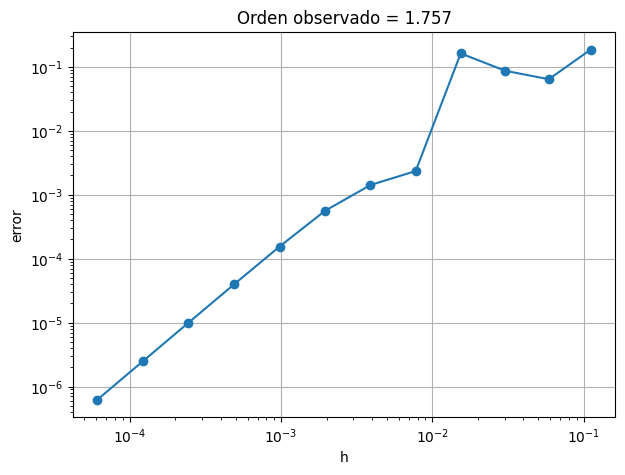

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.loglog(
    hs,
    errores,
    'o-'
)

plt.xlabel("h")
plt.ylabel("error")

plt.grid(True)

plt.title(
    f"Orden observado = {p:.3f}"
)

plt.show()